In [1]:
import pandas as pd
df = pd.read_parquet(r"C:\QP2\data\meta\sp500_universe.parquet")
print(df.columns.tolist())
print(df.head())

['ticker_sp', 'ticker_yahoo', 'cik', 'security_name', 'GICS Sector', 'GICS Sub-Industry']
  ticker_sp ticker_yahoo         cik        security_name  \
0       MMM          MMM  0000066740                   3M   
1       AOS          AOS  0000091142          A. O. Smith   
2       ABT          ABT  0000001800  Abbott Laboratories   
3      ABBV         ABBV  0001551152               AbbVie   
4       ACN          ACN  0001467373            Accenture   

              GICS Sector               GICS Sub-Industry  
0             Industrials        Industrial Conglomerates  
1             Industrials               Building Products  
2             Health Care           Health Care Equipment  
3             Health Care                   Biotechnology  
4  Information Technology  IT Consulting & Other Services  


In [3]:
import pandas as pd
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
resp = requests.get(url, headers=headers)
tables = pd.read_html(StringIO(resp.text))
changes = tables[1]
changes.to_csv(r"C:\QP2\data\meta\sp500_changes.csv", index=False)
print(changes.columns.tolist())
print(changes.shape)
print(changes.head(10))

[('Effective Date', 'Effective Date'), ('Added', 'Ticker'), ('Added', 'Security'), ('Removed', 'Ticker'), ('Removed', 'Security'), ('Reason', 'Reason')]
(389, 6)
      Effective Date  Added                              Removed  \
      Effective Date Ticker                     Security  Ticker   
0   February 9, 2026   CIEN                        Ciena     DAY   
1  December 22, 2025    CRH                          CRH     LKQ   
2  December 22, 2025   CVNA                      Carvana    SOLS   
3  December 22, 2025    FIX          Comfort Systems USA     MHK   
4  December 11, 2025   ARES              Ares Management       K   
5  November 28, 2025   SNDK                      Sandisk     IPG   
6   November 4, 2025    NaN                          NaN     EMN   
7   November 3, 2025      Q            Qnity Electronics     NaN   
8   October 31, 2025    NaN                          NaN     KMX   
9   October 30, 2025   SOLS  Solstice Advanced Materials     NaN   

                     

In [4]:
# 컬럼 정리
changes.columns = ['date', 'added_ticker', 'added_name', 'removed_ticker', 'removed_name', 'reason']
changes['date'] = pd.to_datetime(changes['date'])
changes = changes.sort_values('date').reset_index(drop=True)

print(f"기간: {changes['date'].min()} ~ {changes['date'].max()}")
print(f"총 {len(changes)}건")
print(f"\n최초 10건:")
print(changes.head(10).to_string())
print(f"\n최근 10건:")
print(changes.tail(10).to_string())

# 저장 (정리된 버전)
changes.to_parquet(r"C:\QP2\data\meta\sp500_changes.parquet", index=False)
print("\n✅ 저장 완료: sp500_changes.parquet")

기간: 1976-07-01 00:00:00 ~ 2026-02-09 00:00:00
총 389건

최초 10건:
        date added_ticker                     added_name removed_ticker              removed_name                                                                                                                                       reason
0 1976-07-01          DIS        The Walt Disney Company            AYE          Allegheny Energy  Major restructuring of S&P 500 to have fewer industrials and utilities, and more financial companies to add "new strength and breadth"[273]
1 1976-07-01          BUD                 Anheuser Busch            HNG       Houston Natural Gas  Major restructuring of S&P 500 to have fewer industrials and utilities, and more financial companies to add "new strength and breadth"[273]
2 1994-09-30          NCC                  National City            MCK                  McKesson                                                                                         McKesson sold PCS Health Services t

In [5]:
# =============================================================================
# 🔨 07_Test2_Survive — 셀 0: Point-in-Time S&P500 유니버스 구축
# =============================================================================
#
# [목적]
# 현재 S&P500 구성종목을 과거에 소급 적용하는 생존편향을 제거.
# 위키피디아 S&P500 변경 이력(sp500_changes.parquet)을 사용하여
# 각 월별로 "그 시점의 실제 S&P500 구성종목"을 역산.
#
# [로직]
# 1. 기준점: 2026-02 현재 S&P500 = sp500_universe.parquet (503종목)
# 2. sp500_changes를 최신→과거 역순으로 탐색:
#    - added_ticker가 있으면 → 해당 날짜 이전에는 유니버스에서 제거
#      (편입 전이니까 S&P500이 아니었음)
#    - removed_ticker가 있으면 → 해당 날짜 이전에는 유니버스에 추가
#      (퇴출 전이니까 S&P500이었음)
# 3. 월말 기준으로 스냅샷 생성
#
# [산출물]
# data/interim/sp500_pit_universe.parquet
#   컬럼: date, ticker_yahoo
#   각 행 = "이 날짜에 이 종목이 S&P500 구성종목이었다"
#
# [주의]
# - 위키피디아 데이터가 100% 완벽하지 않을 수 있음 (누락, 오타)
# - ticker 변경(리네이밍)은 반영 안 됨 — 추후 수동 보정 필요 시 대응
# - 1976년부터 이력 있으나 백테스트 시작은 2013-06 → 2013년 이전은 참고용
# =============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

QP2_ROOT = Path(r"C:\QP2")
DATA_DIR = QP2_ROOT / "data"
META_DIR = DATA_DIR / "meta"
INTERIM  = DATA_DIR / "interim"

# ─── 1. 데이터 로드 ───────────────────────────────────────────────────────────

# 현재 S&P500 구성종목
universe = pd.read_parquet(META_DIR / "sp500_universe.parquet")
current_tickers = set(universe["ticker_yahoo"].dropna().unique())
print(f"현재 S&P500: {len(current_tickers)}종목")

# 변경 이력
changes = pd.read_parquet(META_DIR / "sp500_changes.parquet")
changes["date"] = pd.to_datetime(changes["date"])
changes = changes.sort_values("date", ascending=False).reset_index(drop=True)  # 최신→과거
print(f"변경 이력: {len(changes)}건 ({changes['date'].min().date()} ~ {changes['date'].max().date()})")

# ─── 2. 변경 이력에서 ticker 매핑 확인 ────────────────────────────────────────

# Yahoo ticker와 S&P ticker가 다를 수 있음 (BRK.B vs BRK-B 등)
# sp500_universe에 ticker_sp, ticker_yahoo 둘 다 있으니 매핑 생성
sp_to_yahoo = universe.set_index("ticker_sp")["ticker_yahoo"].to_dict()

def to_yahoo_ticker(sp_ticker):
    """S&P ticker → Yahoo ticker 변환. 매핑 없으면 . → - 치환."""
    if pd.isna(sp_ticker) or sp_ticker == "":
        return None
    sp_ticker = str(sp_ticker).strip()
    if sp_ticker in sp_to_yahoo:
        return sp_to_yahoo[sp_ticker]
    # . → - 치환 (BRK.B → BRK-B)
    yahoo_guess = sp_ticker.replace(".", "-")
    return yahoo_guess

# ─── 3. 역순 탐색으로 월별 유니버스 구축 ──────────────────────────────────────

# 백테스트 기간 정의
bt_start = pd.Timestamp("2010-01-01")  # 여유분 (팩터 계산에 lookback 필요)
bt_end = pd.Timestamp("2026-02-28")

# 월말 날짜 생성
monthly_dates = pd.date_range(bt_start, bt_end, freq="ME")

# 시작점: 현재 유니버스 복사
live_set = current_tickers.copy()

# 변경 이력을 날짜 기준으로 그룹핑 (역순)
changes_sorted = changes.sort_values("date", ascending=False)

# 날짜별 변경 사항 딕셔너리 (날짜 → [(added, removed), ...])
change_events = {}
for _, row in changes_sorted.iterrows():
    dt = row["date"]
    added = to_yahoo_ticker(row["added_ticker"])
    removed = to_yahoo_ticker(row["removed_ticker"])
    if dt not in change_events:
        change_events[dt] = []
    change_events[dt].append({"added": added, "removed": removed})

# 역순으로 월별 스냅샷 생성
# 현재 → 과거로 가면서, 각 변경 이벤트를 "되돌림"
snapshots = {}
event_dates = sorted(change_events.keys(), reverse=True)
event_idx = 0

for dt in tqdm(sorted(monthly_dates, reverse=True), desc="PIT Universe"):
    # 이 월말보다 이후이고 아직 처리 안 한 변경 이벤트 적용
    while event_idx < len(event_dates) and event_dates[event_idx] > dt:
        for event in change_events[event_dates[event_idx]]:
            # "되돌림": 편입(added) → 이전에는 없었으니 제거
            if event["added"] and event["added"] in live_set:
                live_set.remove(event["added"])
            # "되돌림": 퇴출(removed) → 이전에는 있었으니 추가
            if event["removed"]:
                live_set.add(event["removed"])
        event_idx += 1

    snapshots[dt] = live_set.copy()

# ─── 4. DataFrame 변환 ───────────────────────────────────────────────────────

records = []
for dt in sorted(snapshots.keys()):
    for ticker in sorted(snapshots[dt]):
        records.append({"date": dt, "ticker_yahoo": ticker})

pit_universe = pd.DataFrame(records)
pit_universe["date"] = pd.to_datetime(pit_universe["date"])

print(f"\n{'='*60}")
print(f"Point-in-Time 유니버스 구축 완료")
print(f"{'='*60}")
print(f"  기간: {pit_universe['date'].min().date()} ~ {pit_universe['date'].max().date()}")
print(f"  총 행: {len(pit_universe):,}")
print(f"  월별 평균 종목 수: {pit_universe.groupby('date')['ticker_yahoo'].count().mean():.0f}")

# 월별 종목 수 추이
monthly_count = pit_universe.groupby("date")["ticker_yahoo"].count()
print(f"\n  종목 수 추이 (5년 간격):")
for yr in [2010, 2013, 2015, 2018, 2020, 2023, 2025]:
    mask = monthly_count.index.year == yr
    if mask.any():
        avg = monthly_count[mask].mean()
        print(f"    {yr}: 평균 {avg:.0f}종목")

# ─── 5. 현재 유니버스 대비 차이 확인 ──────────────────────────────────────────

# 2013-06 기준 PIT vs 현재
pit_2013 = set(pit_universe[pit_universe["date"] == "2013-06-28"]["ticker_yahoo"])
only_current = current_tickers - pit_2013  # 현재는 있지만 2013에는 없었던 종목
only_2013 = pit_2013 - current_tickers      # 2013에는 있었지만 현재는 퇴출된 종목

print(f"\n  2013-06 vs 현재 비교:")
print(f"    현재 S&P500: {len(current_tickers)}종목")
print(f"    2013-06 PIT: {len(pit_2013)}종목")
print(f"    현재만 있음 (2013엔 없었음): {len(only_current)}종목")
print(f"    2013만 있음 (현재 퇴출됨): {len(only_2013)}종목")

if len(only_current) > 0:
    print(f"\n    현재만 있는 종목 예시 (최대 20개):")
    for t in sorted(only_current)[:20]:
        print(f"      {t}")

if len(only_2013) > 0:
    print(f"\n    2013만 있는 종목 예시 (최대 20개):")
    for t in sorted(only_2013)[:20]:
        print(f"      {t}")

# ─── 6. 저장 ──────────────────────────────────────────────────────────────────

pit_universe.to_parquet(INTERIM / "sp500_pit_universe.parquet", index=False)
print(f"\n✅ 저장: sp500_pit_universe.parquet")
print(f"   {len(pit_universe):,} rows")

현재 S&P500: 503종목
변경 이력: 389건 (1976-07-01 ~ 2026-02-09)


PIT Universe: 100%|██████████| 194/194 [00:00<00:00, 66364.49it/s]


Point-in-Time 유니버스 구축 완료
  기간: 2010-01-31 ~ 2026-02-28
  총 행: 98,199
  월별 평균 종목 수: 506

  종목 수 추이 (5년 간격):
    2010: 평균 510종목
    2013: 평균 507종목
    2015: 평균 508종목
    2018: 평균 506종목
    2020: 평균 506종목
    2023: 평균 503종목
    2025: 평균 503종목

  2013-06 vs 현재 비교:
    현재 S&P500: 503종목
    2013-06 PIT: 0종목
    현재만 있음 (2013엔 없었음): 503종목
    2013만 있음 (현재 퇴출됨): 0종목

    현재만 있는 종목 예시 (최대 20개):
      A
      AAPL
      ABBV
      ABNB
      ABT
      ACGL
      ACN
      ADBE
      ADI
      ADM
      ADP
      ADSK
      AEE
      AEP
      AES
      AFL
      AIG
      AIZ
      AJG
      AKAM

✅ 저장: sp500_pit_universe.parquet
   98,199 rows


In [7]:
pit = pd.read_parquet(r"C:\QP2\data\interim\sp500_pit_universe.parquet")
print(pit.columns.tolist())
print(pit.dtypes)
print(pit.head())

['date', 'ticker_yahoo']
date            datetime64[us]
ticker_yahoo               str
dtype: object
        date ticker_yahoo
0 2010-01-31            A
1 2010-01-31           AA
2 2010-01-31         AAPL
3 2010-01-31          ABT
4 2010-01-31          ACE


📦 데이터 로드
  시그널 로드 완료
  ret_1m: (770, 277)

  기존 panel: (76456, 15)
  기간: 2013-06-30 00:00:00 ~ 2026-01-31 00:00:00
  고유 종목: 503

🔨 PIT 유니버스 적용
  기존 panel:  76,456 rows, 503 tickers
  PIT panel:   62,159 rows, 503 tickers
  제거된 행:   14,297 (18.7%)

  월별 종목 수 차이:
    평균: 94.1종목 제거
    최대: 176종목 제거
    최소: 0종목 제거

📊 PIT 기준 벤치마크(EW) 재계산
  기존 ret_1m: 월평균 199종목
  PIT ret_1m:  월평균 97종목

🔨 백테스트: 기존(생존편향) vs PIT(편향제거)

  종합 성과 — 기존 vs PIT vs SPY
                                CAGR   Sharpe    MaxDD   t-stat
  ------------------------------------------------------------
  SPY                         11.9%     0.87  -24.8%
  EW BM (기존)                  14.4%     0.99  -24.1%
  EW BM (PIT)                 14.0%     0.95  -24.7%
  Model (기존)                  16.9%     0.96  -16.9%     0.85
  Model (PIT)                 11.7%     0.74  -17.8%    -0.64

  생존편향 영향:
    BM Sharpe:    0.99 → 0.95 (-0.04)
    Model Sharpe: 0.96 → 0.74 (-0.22)
    Model CAGR:   16.9% → 11.7% (-5.2%)

  vs SPY:
    기존: WI

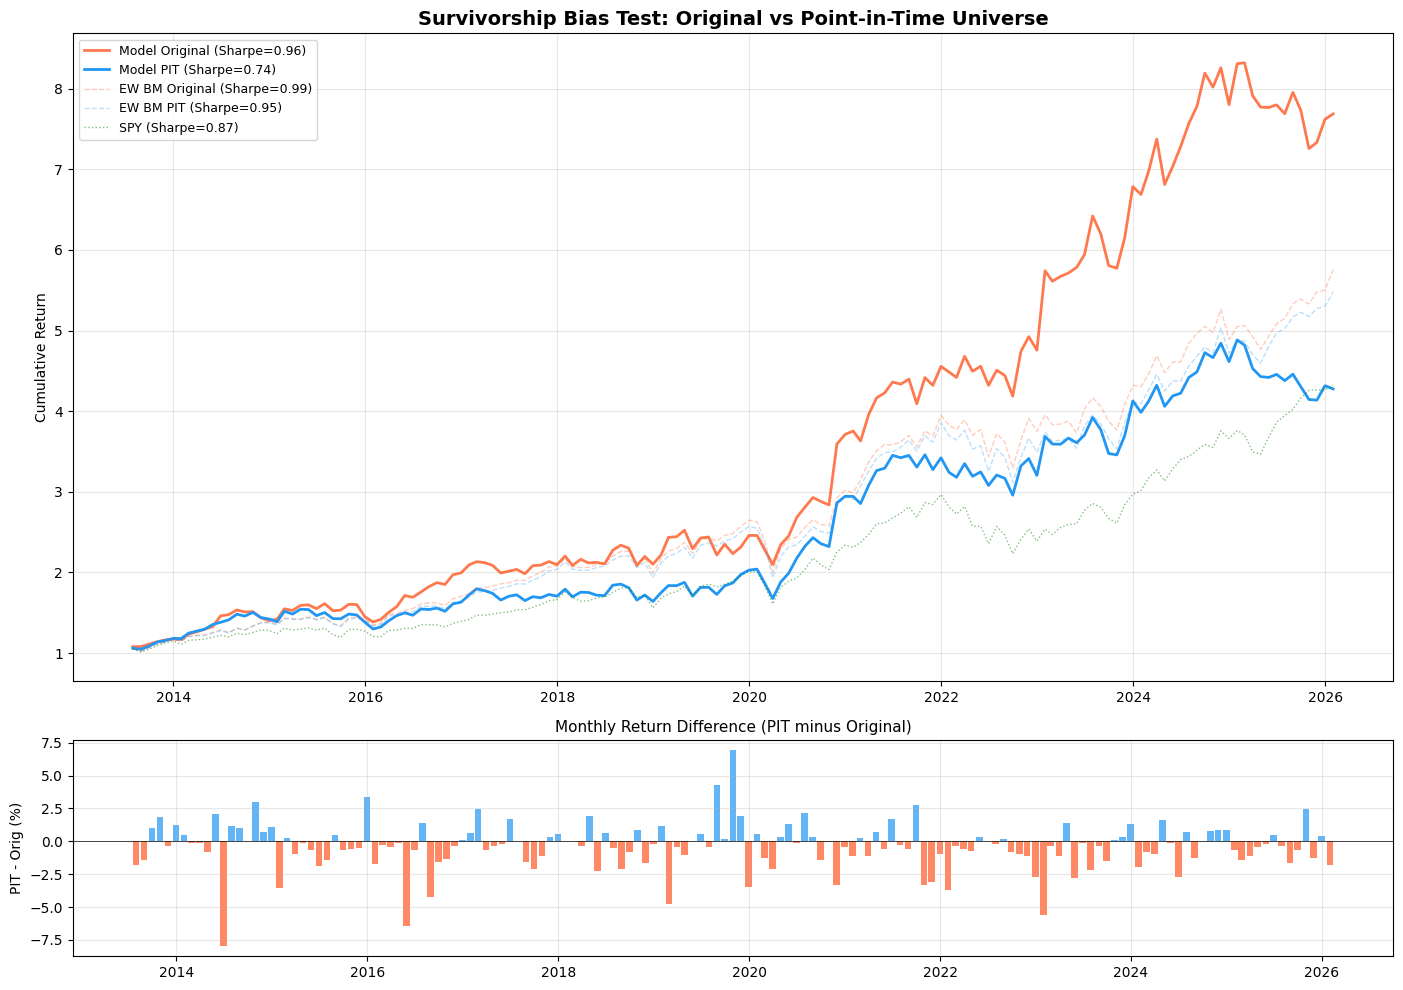


  판정
  → ⚠ 생존편향 영향 유의미 (Sharpe +0.22)
    기존 모델 성과의 일부가 생존편향에 의한 것.
  → ⚠ PIT 기준으로 SPY 대비 LOSE. 알파 재검토 필요.


In [12]:
# =============================================================================
# 🔨 07_Test2_Survive — 셀 5: PIT 필터 적용 + 생존편향 비교 백테스트
# =============================================================================
#
# [목적]
# 셀 3에서 구축한 sp500_pit_universe.parquet를 사용하여
# 06_TheForge의 panel에서 "해당 시점에 S&P500이 아닌 종목"을 제거.
# 기존(생존편향 있음) vs PIT(생존편향 제거) 성과 비교.
#
# [작업]
# 1. 06_TheForge 환경 재로드 (panel, ret_1m, regime_map 등)
# 2. PIT 유니버스로 panel 필터링
# 3. PIT 기준 ret_1m (EW 벤치마크) 재계산
# 4. 기존 가중치로 PIT 백테스트 실행
# 5. 기존(original) vs PIT 성과 비교
#
# [핵심 질문]
# 생존편향 제거하면 Sharpe가 얼마나 떨어지나?
# Bull/Bear/Neutral 레짐별로 영향이 다른가?
# SPY 대비 여전히 이기나?
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

# ─── 경로 ─────────────────────────────────────────────────────────────────────

QP2_ROOT = Path(r"C:\QP2")
DATA_DIR = QP2_ROOT / "data"
INTERIM  = DATA_DIR / "interim"
META_DIR = DATA_DIR / "meta"

TOP_N    = 30
COST_BP  = 20
BT_START = "2013-06"
BT_END   = "2026-02"

# ─── 유틸리티 함수 ────────────────────────────────────────────────────────────

def calc_perf(cum_ret):
    total = cum_ret.iloc[-1] / cum_ret.iloc[0]
    years = len(cum_ret) / 12
    cagr  = total ** (1/years) - 1
    monthly_ret = cum_ret.pct_change().dropna()
    sharpe = monthly_ret.mean() / monthly_ret.std() * np.sqrt(12) if monthly_ret.std() > 0 else 0
    dd = cum_ret / cum_ret.cummax() - 1
    maxdd = dd.min()
    return {"CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd}

def calc_tstat(excess_monthly):
    n = len(excess_monthly)
    if n < 3:
        return 0.0
    return excess_monthly.mean() / (excess_monthly.std() / np.sqrt(n))

# ─── 1. 기존 Panel + 시그널 로드 (06_TheForge 동일) ──────────────────────────

print("=" * 70)
print("📦 데이터 로드")
print("=" * 70)

SAVE_DIR = INTERIM

# H
h_sig = pd.read_parquet(SAVE_DIR / "h_signal.parquet")
h_sig["date"] = pd.to_datetime(h_sig["date"])

# D
d_sig = pd.read_parquet(SAVE_DIR / "d_signal.parquet")
d_sig["date"] = pd.to_datetime(d_sig["date"])

# A-3
a3_sig = pd.read_parquet(SAVE_DIR / "a3_signal.parquet")
a3_sig["date"] = pd.to_datetime(a3_sig["date"])

# P-5 + E-5
p5e5_sig = pd.read_parquet(SAVE_DIR / "p5_e5_signal.parquet")
p5e5_sig["date"] = pd.to_datetime(p5e5_sig["date"])

# G-1
g1_sig = pd.read_parquet(SAVE_DIR / "g1_signal.parquet")
g1_sig["date"] = pd.to_datetime(g1_sig["date"])

# T-1
t1_events = pd.read_parquet(SAVE_DIR / "t1_events.parquet")
if len(t1_events) > 0:
    t1_events["date"] = pd.to_datetime(t1_events["date"])

# F-1
f_sig = pd.read_parquet(SAVE_DIR / "fscore_signal.parquet")
f_sig["date"] = pd.to_datetime(f_sig["date"])
f_cols = ["date", "ticker", "fscore"] if "ticker" in f_sig.columns else ["date", "ticker_yahoo", "fscore"]
f_sig = f_sig[f_cols].copy()
if "ticker_yahoo" in f_sig.columns:
    f_sig = f_sig.rename(columns={"ticker_yahoo": "ticker"})

# P-7
p7_sig = pd.read_parquet(SAVE_DIR / "p7_signal_panel.parquet")
p7_sig["date"] = pd.to_datetime(p7_sig["date"])
if "nsi_score" not in p7_sig.columns and "nsi_z" in p7_sig.columns:
    p7_sig["nsi_score"] = -p7_sig["nsi_z"]
p7_sig = p7_sig[["date", "ticker", "nsi_score"]].copy()

# 레짐
regime_v4 = pd.read_parquet(SAVE_DIR / "regime_v4.parquet")
regime_v4.index = pd.to_datetime(regime_v4.index)
regime_v4 = regime_v4.reset_index().rename(columns={"index": "date"})
regime_v4["date"] = pd.to_datetime(regime_v4["date"]) + pd.offsets.MonthEnd(0)
regime_map = regime_v4.set_index("date")[["regime", "bear_phase"]].to_dict("index")

# ret_1m (기존 — 생존편향 있음)
ret_1m_orig = pd.read_parquet(SAVE_DIR / "ret_1m_wide.parquet")
if "date" in ret_1m_orig.columns:
    ret_1m_orig = ret_1m_orig.set_index("date")
ret_1m_orig.index = pd.to_datetime(ret_1m_orig.index)

# ticker_to_sector
universe = pd.read_parquet(META_DIR / "sp500_universe.parquet")
ticker_to_sector = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()

print(f"  시그널 로드 완료")
print(f"  ret_1m: {ret_1m_orig.shape}")

# ─── 2. Panel 구축 (기존 방식) ────────────────────────────────────────────────

panel_orig = h_sig[["date", "ticker", "h_z"]].copy()
panel_orig = panel_orig.merge(d_sig[["date", "ticker", "d1_z", "d3_z"]], on=["date", "ticker"], how="left")
panel_orig = panel_orig.merge(a3_sig[["date", "ticker", "a3_z"]], on=["date", "ticker"], how="left")
panel_orig = panel_orig.merge(p5e5_sig[["date", "ticker", "p5_z", "e5_z"]], on=["date", "ticker"], how="left")
panel_orig = panel_orig.merge(g1_sig[["date", "ticker", "g1_bull_z", "g1_bear_z", "g1b_flag"]], on=["date", "ticker"], how="left")
panel_orig = panel_orig.merge(p7_sig, on=["date", "ticker"], how="left")
panel_orig = panel_orig.merge(f_sig, on=["date", "ticker"], how="left")

regime_slim = regime_v4[["date", "regime", "bear_phase"]].copy()
panel_orig = panel_orig.merge(regime_slim, on="date", how="left")
panel_orig = panel_orig[(panel_orig["date"] >= BT_START) & (panel_orig["date"] <= BT_END)]

print(f"\n  기존 panel: {panel_orig.shape}")
print(f"  기간: {panel_orig['date'].min()} ~ {panel_orig['date'].max()}")
print(f"  고유 종목: {panel_orig['ticker'].nunique()}")

# ─── 3. PIT 유니버스 로드 + 필터 적용 ────────────────────────────────────────

print(f"\n{'='*70}")
print("🔨 PIT 유니버스 적용")
print("=" * 70)

pit = pd.read_parquet(INTERIM / "sp500_pit_universe.parquet")
pit["date"] = pd.to_datetime(pit["date"])

# ★ 날짜 매칭 수정: PIT(MonthEnd)와 panel(영업일)의 day가 다름
#   → year-month 기준으로 조인
pit["ym"] = pit["date"].dt.to_period("M")
panel_orig_ym = panel_orig.copy()
panel_orig_ym["ym"] = panel_orig_ym["date"].dt.to_period("M")

panel_pit = panel_orig_ym.merge(
    pit.rename(columns={"ticker_yahoo": "ticker"})[["ym", "ticker"]],
    on=["ym", "ticker"],
    how="inner"
).drop(columns=["ym"])

removed_rows = len(panel_orig) - len(panel_pit)
removed_pct = removed_rows / len(panel_orig) * 100

print(f"  기존 panel:  {len(panel_orig):,} rows, {panel_orig['ticker'].nunique()} tickers")
print(f"  PIT panel:   {len(panel_pit):,} rows, {panel_pit['ticker'].nunique()} tickers")
print(f"  제거된 행:   {removed_rows:,} ({removed_pct:.1f}%)")

# 월별 종목 수 비교
orig_monthly = panel_orig.groupby("date")["ticker"].nunique()
pit_monthly = panel_pit.groupby("date")["ticker"].nunique()
diff_monthly = orig_monthly - pit_monthly

print(f"\n  월별 종목 수 차이:")
print(f"    평균: {diff_monthly.mean():.1f}종목 제거")
print(f"    최대: {diff_monthly.max():.0f}종목 제거")
print(f"    최소: {diff_monthly.min():.0f}종목 제거")

# ─── 4. PIT 기준 ret_1m 재계산 ───────────────────────────────────────────────

print(f"\n{'='*70}")
print("📊 PIT 기준 벤치마크(EW) 재계산")
print("=" * 70)

# 주가 원본에서 월간 수익률 재계산
px_wide = pd.read_parquet(INTERIM / "yahoo_adjclose_wide.parquet")
if "date" in px_wide.columns:
    px_wide = px_wide.set_index("date")
px_wide.index = pd.to_datetime(px_wide.index)

# 월말 리샘플 + 수익률
px_monthly = px_wide.resample("ME").last()
ret_1m_all = px_monthly.pct_change().dropna(how="all")

# PIT 필터 적용된 ret_1m 생성
# 각 월별로 PIT 유니버스에 있는 종목만 남기고 나머지는 NaN
ret_1m_pit = ret_1m_all.copy()

# PIT를 ym→ticker set 딕셔너리로 변환 (빠른 lookup)
pit_ym_sets = pit.groupby("ym")["ticker_yahoo"].apply(set).to_dict()

for dt in ret_1m_pit.index:
    ym = dt.to_period("M")
    pit_tickers_dt = pit_ym_sets.get(ym, set())
    non_pit_cols = [c for c in ret_1m_pit.columns if c not in pit_tickers_dt]
    ret_1m_pit.loc[dt, non_pit_cols] = np.nan

print(f"  기존 ret_1m: 월평균 {ret_1m_orig.notna().sum(axis=1).mean():.0f}종목")
print(f"  PIT ret_1m:  월평균 {ret_1m_pit.notna().sum(axis=1).mean():.0f}종목")

# ─── 5. backtest_weighted 함수 정의 ──────────────────────────────────────────

def backtest_weighted(panel_df, ret_1m_df, regime_map_dict, weight_set,
                      t1_events_df, ticker_to_sector_dict,
                      top_n=30, cost_bp=20, avoid_penalty=-2.0,
                      t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    all_dates = sorted(panel_df["date"].unique())
    results = []
    prev_holdings = set()
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        regime_info = regime_map_dict.get(dt, None)
        if regime_info is None:
            dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
            regime_info = regime_map_dict.get(dt_me, None)
        if regime_info is None:
            continue
        regime = regime_info["regime"]
        bear_phase = regime_info.get("bear_phase", "")
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        weights = weight_set.get(regime, {})
        if not weights:
            continue
        factor_cols = [col for col in weights.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        weight_arr = np.array([weights[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        if regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        if regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        if regime == "Bull" and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "")
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        valid = month_data.dropna(subset=["composite_z"])
        top_n_actual = min(top_n, max(10, len(valid)))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        results.append({"date": next_dt, "regime": regime, "bear_phase": bear_phase,
                        "port_ret_net": port_ret - cost, "bm_ret": bm_ret, "turnover": turnover})
        prev_holdings = curr_set
    df = pd.DataFrame(results)
    if len(df) == 0:
        return df
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["excess_net"] = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"] = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"] = (1 + df["bm_ret"]).cumprod()
    return df

# ─── 6. 백테스트: 기존 vs PIT ─────────────────────────────────────────────────

print(f"\n{'='*70}")
print("🔨 백테스트: 기존(생존편향) vs PIT(편향제거)")
print("=" * 70)

FINAL_WEIGHTS = {
    "Bull":    {"h_z": 0.0, "g1_bull_z": 1.8, "nsi_score": 0.3},
    "Bear":    {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7},
    "Neutral": {"h_z": 0.5, "d3_z": 1.1},
}

# 기존 (생존편향 있음)
bt_orig = backtest_weighted(
    panel_orig, ret_1m_orig, regime_map, FINAL_WEIGHTS,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

# PIT (생존편향 제거)
bt_pit = backtest_weighted(
    panel_pit, ret_1m_pit, regime_map, FINAL_WEIGHTS,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

perf_orig = calc_perf(bt_orig["cum_port"])
perf_pit = calc_perf(bt_pit["cum_port"])
bm_orig = calc_perf(bt_orig["cum_bm"])
bm_pit = calc_perf(bt_pit["cum_bm"])
tstat_orig = calc_tstat(bt_orig["excess_net"])
tstat_pit = calc_tstat(bt_pit["excess_net"])

# SPY
spy_raw = pd.read_parquet(INTERIM / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()
common_idx = bt_orig.index.intersection(spy_ret.index)
cum_spy = (1 + spy_ret.loc[common_idx]).cumprod()
spy_perf = calc_perf(cum_spy)

# ─── 7. 종합 비교 ────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  종합 성과 — 기존 vs PIT vs SPY")
print(f"{'='*70}")
print(f"  {'':25s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*60}")
print(f"  {'SPY':25s} {spy_perf['CAGR']:>7.1%} {spy_perf['Sharpe']:>8.2f} "
      f"{spy_perf['MaxDD']:>7.1%}")
print(f"  {'EW BM (기존)':25s} {bm_orig['CAGR']:>7.1%} {bm_orig['Sharpe']:>8.2f} "
      f"{bm_orig['MaxDD']:>7.1%}")
print(f"  {'EW BM (PIT)':25s} {bm_pit['CAGR']:>7.1%} {bm_pit['Sharpe']:>8.2f} "
      f"{bm_pit['MaxDD']:>7.1%}")
print(f"  {'Model (기존)':25s} {perf_orig['CAGR']:>7.1%} {perf_orig['Sharpe']:>8.2f} "
      f"{perf_orig['MaxDD']:>7.1%} {tstat_orig:>8.2f}")
print(f"  {'Model (PIT)':25s} {perf_pit['CAGR']:>7.1%} {perf_pit['Sharpe']:>8.2f} "
      f"{perf_pit['MaxDD']:>7.1%} {tstat_pit:>8.2f}")

print(f"\n  생존편향 영향:")
print(f"    BM Sharpe:    {bm_orig['Sharpe']:.2f} → {bm_pit['Sharpe']:.2f} ({bm_pit['Sharpe']-bm_orig['Sharpe']:+.2f})")
print(f"    Model Sharpe: {perf_orig['Sharpe']:.2f} → {perf_pit['Sharpe']:.2f} ({perf_pit['Sharpe']-perf_orig['Sharpe']:+.2f})")
print(f"    Model CAGR:   {perf_orig['CAGR']:.1%} → {perf_pit['CAGR']:.1%} ({perf_pit['CAGR']-perf_orig['CAGR']:+.1%})")

# vs SPY
print(f"\n  vs SPY:")
print(f"    기존: {'WIN' if perf_orig['Sharpe'] > spy_perf['Sharpe'] else 'LOSE'} (Sharpe {perf_orig['Sharpe']:.2f} vs {spy_perf['Sharpe']:.2f})")
print(f"    PIT:  {'WIN' if perf_pit['Sharpe'] > spy_perf['Sharpe'] else 'LOSE'} (Sharpe {perf_pit['Sharpe']:.2f} vs {spy_perf['Sharpe']:.2f})")

# ─── 8. 레짐별 분해 ──────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  레짐별 비교")
print(f"{'='*70}")
print(f"  {'레짐':10s} {'':8s} {'Sharpe':>8s} {'BM_Shp':>8s} {'Excess_M':>9s} {'판정':>6s}")
print(f"  {'-'*55}")

for regime in ["Bull", "Bear", "Neutral"]:
    for label, bt in [("기존", bt_orig), ("PIT", bt_pit)]:
        sub = bt[bt["regime"] == regime]
        if len(sub) < 2:
            continue
        cum = (1 + sub["port_ret_net"]).cumprod()
        cum_bm = (1 + sub["bm_ret"]).cumprod()
        rp = calc_perf(cum)
        rb = calc_perf(cum_bm)
        excess_m = sub["excess_net"].mean() * 100
        flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
        print(f"  {regime:10s} {label:8s} {rp['Sharpe']:>8.2f} {rb['Sharpe']:>8.2f} "
              f"{excess_m:>+8.2f}% {flag:>6s}")
    print()

# ─── 9. 차트 ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.plot(bt_orig.index, bt_orig["cum_port"],
        label=f"Model Original (Sharpe={perf_orig['Sharpe']:.2f})",
        linewidth=2, color="#FF5722", alpha=0.8)
ax.plot(bt_pit.index, bt_pit["cum_port"],
        label=f"Model PIT (Sharpe={perf_pit['Sharpe']:.2f})",
        linewidth=2, color="#2196F3")
ax.plot(bt_orig.index, bt_orig["cum_bm"],
        label=f"EW BM Original (Sharpe={bm_orig['Sharpe']:.2f})",
        linewidth=1, color="#FF5722", alpha=0.3, linestyle="--")
ax.plot(bt_pit.index, bt_pit["cum_bm"],
        label=f"EW BM PIT (Sharpe={bm_pit['Sharpe']:.2f})",
        linewidth=1, color="#2196F3", alpha=0.3, linestyle="--")
ax.plot(common_idx, cum_spy.values,
        label=f"SPY (Sharpe={spy_perf['Sharpe']:.2f})",
        linewidth=1, color="green", alpha=0.5, linestyle=":")

ax.set_title("Survivorship Bias Test: Original vs Point-in-Time Universe", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylabel("Cumulative Return")
ax.grid(True, alpha=0.3)

# 하단: PIT - Original 월간 차이
ax2 = axes[1]
pit_minus_orig = bt_pit["port_ret_net"] - bt_orig["port_ret_net"]
colors = ["#2196F3" if x >= 0 else "#FF5722" for x in pit_minus_orig]
ax2.bar(pit_minus_orig.index, pit_minus_orig.values * 100, color=colors, alpha=0.7, width=25)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("PIT - Orig (%)")
ax2.set_title("Monthly Return Difference (PIT minus Original)", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── 10. 판정 ─────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  판정")
print(f"{'='*70}")

bias_sharpe = perf_orig["Sharpe"] - perf_pit["Sharpe"]
bias_cagr = perf_orig["CAGR"] - perf_pit["CAGR"]

if bias_sharpe > 0.05:
    print(f"  → ⚠ 생존편향 영향 유의미 (Sharpe {bias_sharpe:+.2f})")
    print(f"    기존 모델 성과의 일부가 생존편향에 의한 것.")
elif bias_sharpe > 0:
    print(f"  → 생존편향 영향 경미 (Sharpe {bias_sharpe:+.2f})")
    print(f"    모델 성과 대부분이 실제 알파.")
else:
    print(f"  → 생존편향 영향 없음 또는 역방향 (Sharpe {bias_sharpe:+.2f})")
    print(f"    PIT가 오히려 나음 = 기존 모델이 보수적이었음.")

if perf_pit["Sharpe"] > spy_perf["Sharpe"]:
    print(f"  → ✅ PIT 기준으로도 SPY 대비 WIN!")
else:
    print(f"  → ⚠ PIT 기준으로 SPY 대비 LOSE. 알파 재검토 필요.")

In [14]:
# panel ticker vs PIT ticker 비교
panel_tickers = set(panel_orig[panel_orig["date"] == panel_orig["date"].iloc[0]]["ticker"])
pit_ym = pit[pit["ym"] == panel_orig["date"].iloc[0].to_period("M")]
pit_tickers = set(pit_ym["ticker_yahoo"])

print(f"Panel tickers (첫 달): {len(panel_tickers)}")
print(f"PIT tickers (첫 달): {len(pit_tickers)}")
print(f"교집합: {len(panel_tickers & pit_tickers)}")
print(f"Panel에만: {len(panel_tickers - pit_tickers)}")
print(f"PIT에만: {len(pit_tickers - panel_tickers)}")

# Panel에만 있는 종목 예시
print(f"\nPanel에만 있는 종목 (처음 20개):")
for t in sorted(panel_tickers - pit_tickers)[:20]:
    print(f"  {t}")

print(f"\nPIT에만 있는 종목 (처음 20개):")
for t in sorted(pit_tickers - panel_tickers)[:20]:
    print(f"  {t}")

Panel tickers (첫 달): 503
PIT tickers (첫 달): 507
교집합: 327
Panel에만: 176
PIT에만: 180

Panel에만 있는 종목 (처음 20개):
  ABNB
  ACGL
  AJG
  ALB
  ALGN
  ALLE
  AMCR
  AME
  ANET
  AOS
  APO
  APP
  ARE
  ARES
  ATO
  AVGO
  AWK
  AXON
  BG
  BKR

PIT에만 있는 종목 (처음 20개):
  AA
  ACE
  ADT
  AET
  AGN
  AIV
  ALTR
  ALXN
  AN
  ANDV
  ANF
  APC
  APOL
  ARG
  ATI
  AVP
  BBBY
  BBWI
  BCR
  BEAM


In [15]:
from pathlib import Path

yahoo_dir = Path(r"C:\QP2\data\raw\yahoo")
existing_files = {f.stem for f in yahoo_dir.glob("*.parquet")}

# PIT에만 있는 종목 (퇴출 종목) 중 Yahoo 데이터 있는지
pit_only = {'AA', 'ACE', 'ADT', 'AET', 'AGN', 'ALV', 'ALTR', 'AN', 'ANDV', 'ANF', 'APC', 'APOL', 'ARG', 'ATI', 'AW', 'BBY', 'BBWI', 'BCR', 'BEAM'}

have = pit_only & existing_files
missing = pit_only - existing_files

print(f"퇴출 종목 중 Yahoo 데이터 있음: {len(have)}")
print(f"퇴출 종목 중 Yahoo 데이터 없음: {len(missing)}")
print(f"\n있는 것: {sorted(have)}")
print(f"없는 것: {sorted(missing)}")

퇴출 종목 중 Yahoo 데이터 있음: 1
퇴출 종목 중 Yahoo 데이터 없음: 18

있는 것: ['BBY']
없는 것: ['AA', 'ACE', 'ADT', 'AET', 'AGN', 'ALTR', 'ALV', 'AN', 'ANDV', 'ANF', 'APC', 'APOL', 'ARG', 'ATI', 'AW', 'BBWI', 'BCR', 'BEAM']


In [16]:
# 셀 5 코드에서 이 줄이 있는지 확인
pit["ym"] = pit["date"].dt.to_period("M")

In [ ]:
#조졌네 ㅋㅋ 

In [17]:
# =============================================================================
# 🔨 07_Test2_Survive — 셀 6: 퇴출 종목 전체 리스트 추출
# =============================================================================
#
# [목적]
# PIT 유니버스에는 있지만 현재 panel에는 없는 종목 = 퇴출 종목.
# 이 종목들의 전체 리스트 + 필요 기간을 확정.
# → 다음 셀에서 Yahoo 주가 다운로드 대상으로 사용.
# =============================================================================

import pandas as pd
from pathlib import Path

INTERIM = Path(r"C:\QP2\data\interim")
META_DIR = Path(r"C:\QP2\data\meta")

# ─── PIT 유니버스 로드 ────────────────────────────────────────────────────────

pit = pd.read_parquet(INTERIM / "sp500_pit_universe.parquet")
pit["date"] = pd.to_datetime(pit["date"])
pit["ym"] = pit["date"].dt.to_period("M")

# 현재 panel 종목 (= 현재 S&P500)
universe = pd.read_parquet(META_DIR / "sp500_universe.parquet")
current_tickers = set(universe["ticker_yahoo"].dropna().unique())

# 백테스트 기간 PIT 종목
bt_start = pd.Timestamp("2013-06-01")
bt_end = pd.Timestamp("2026-02-28")
pit_bt = pit[(pit["date"] >= bt_start) & (pit["date"] <= bt_end)]

# PIT에 있지만 현재 S&P500에 없는 종목 = 퇴출 종목
all_pit_tickers = set(pit_bt["ticker_yahoo"].unique())
delisted = all_pit_tickers - current_tickers

print(f"백테스트 기간 PIT 전체 종목: {len(all_pit_tickers)}")
print(f"현재 S&P500: {len(current_tickers)}")
print(f"퇴출 종목 (PIT에만 존재): {len(delisted)}")

# ─── 퇴출 종목별 필요 기간 ────────────────────────────────────────────────────

# 각 퇴출 종목이 PIT에서 몇 월부터 몇 월까지 있었는지
delisted_periods = []
for ticker in sorted(delisted):
    sub = pit_bt[pit_bt["ticker_yahoo"] == ticker]
    if len(sub) == 0:
        continue
    first = sub["date"].min()
    last = sub["date"].max()
    months = sub["date"].nunique()
    delisted_periods.append({
        "ticker": ticker,
        "first_date": first,
        "last_date": last,
        "months": months,
    })

del_df = pd.DataFrame(delisted_periods).sort_values("ticker")

print(f"\n{'='*70}")
print(f"  퇴출 종목 상세 ({len(del_df)}개)")
print(f"{'='*70}")
print(f"  {'Ticker':>8s}  {'시작':>12s}  {'종료':>12s}  {'개월':>5s}")
print(f"  {'-'*45}")
for _, row in del_df.iterrows():
    print(f"  {row['ticker']:>8s}  {row['first_date'].strftime('%Y-%m'):>12s}  "
          f"{row['last_date'].strftime('%Y-%m'):>12s}  {row['months']:>5d}")

# ─── Yahoo 데이터 존재 여부 확인 ──────────────────────────────────────────────

yahoo_dir = Path(r"C:\QP2\data\raw\yahoo")
existing_files = {f.stem for f in yahoo_dir.glob("*.parquet")}

have = delisted & existing_files
missing = delisted - existing_files

print(f"\n{'='*70}")
print(f"  Yahoo 데이터 현황")
print(f"{'='*70}")
print(f"  이미 있음: {len(have)} / {len(delisted)}")
print(f"  다운로드 필요: {len(missing)} / {len(delisted)}")

if len(have) > 0:
    print(f"\n  있는 종목: {sorted(have)}")
if len(missing) > 0:
    print(f"\n  없는 종목 ({len(missing)}개):")
    for t in sorted(missing):
        row = del_df[del_df["ticker"] == t]
        if len(row) > 0:
            r = row.iloc[0]
            print(f"    {t:>8s}  ({r['first_date'].strftime('%Y-%m')} ~ {r['last_date'].strftime('%Y-%m')}, {r['months']}M)")

# ─── 다운로드 대상 저장 ──────────────────────────────────────────────────────

del_df.to_parquet(INTERIM / "delisted_sp500_needed.parquet", index=False)
print(f"\n✅ 저장: delisted_sp500_needed.parquet ({len(del_df)} tickers)")
print(f"\n※ 다음 셀: Yahoo에서 {len(missing)}개 종목 주가 다운로드")

백테스트 기간 PIT 전체 종목: 749
현재 S&P500: 503
퇴출 종목 (PIT에만 존재): 246

  퇴출 종목 상세 (246개)
    Ticker            시작            종료     개월
  ---------------------------------------------
        AA       2013-06       2016-10     41
       AAL       2015-03       2024-08    114
       AAP       2015-07       2023-07     97
      ABMD       2018-05       2022-11     55
       ACE       2013-06       2015-12     31
       ADS       2013-12       2020-05     78
       ADT       2013-06       2016-04     35
       AET       2013-06       2018-11     66
       AGN       2013-06       2020-04     83
       AIV       2013-06       2020-11     90
       ALK       2016-05       2023-11     91
      ALTR       2013-06       2015-11     30
      ALXN       2013-06       2021-06     97
       AMG       2014-07       2019-11     65
      AMTM       2024-09       2024-11      3
        AN       2013-06       2017-07     50
      ANDV       2013-06       2018-09     64
       ANF       2013-06       2013-11      6